# Notebook 3 — Unbalanced-Growth Path (Phase 2)

This notebook solves the **full stochastic equilibrium** along the $u$-path via backward induction:

1. Solve the 6-equation nonlinear system at each date $t = T, T-1, \ldots, 1$
2. Recover the RoW domestic risk-free rate $R^W_f$
3. Verify all market-clearing conditions ex post
4. Produce the 9-panel equilibrium plot

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Stock_bubble_framework/Agentic_coding`


Plots.GRBackend()

In [2]:
p = ModelParams()
validate_params(p)
paths = generate_exogenous_paths(p)

# ── Phase 1: Solve balanced states ──
T_total = paths.T
balanced_states = Vector{BalancedStateResult}(undef, T_total)
x0_bs = nothing
for t in 1:T_total
    d   = paths.D_US[t] / paths.e_US[t]
    d_W = paths.D_W[t]  / paths.e_W[t]
    ε   = paths.e_W[t]  / paths.e_US[t]
    balanced_states[t] = solve_balanced_state(p, d, d_W, ε; x0=x0_bs)
    bs = balanced_states[t]
    x0_bs = [bs.ω_b, bs.ω_star_b, bs.θ_b, bs.θ_US_star_b, bs.R_f_b]
end
println("Phase 1 complete: balanced states solved.")

Phase 1 complete: balanced states solved.


## 1. The u-Path System (6 × 6)

At each date $t$ on the $u$-path, we solve for 6 unknowns:
$$(\omega_t,\ \omega^*_t,\ \theta_t,\ \theta^*_{US,t},\ R_{f,t},\ Q_{US,t})$$

The 6 equations are:
1. **US $\omega$ FOC**: $\beta(1-\theta_t)\,E_t[\mathcal{M}(R_{US}-R_W)] = \kappa(\omega_t - \bar\omega)$
2. **US $\theta$ FOC**: $\beta\,E_t[\mathcal{M}(R_f - R_p)] = \eta\,\Upsilon'(\theta_t)$
3. **RoW $\omega^*$ FOC**: $\beta(1-\theta^*_{US})\,E_t[\mathcal{M}^*(R_{US}-R_W)] = \kappa(\omega^*_t - \bar\omega^*)$
4. **RoW US-bond FOC**: $\beta\,E_t[\mathcal{M}^*(R_f - R^*_p)] + \chi/\theta^*_{US,t} = 0$
5. **Stock market clearing**: $Q_{US,t} = \omega_t S_t + \omega^*_t S^*_t$
6. **Bond clearing**: $\theta_t A_t + \theta^*_{US,t} A^*_t = 0$

Expectations are two-point: $E_t[f] = \pi f^u + (1-\pi) f^b$, using u-path values at $t+1$ (known from the previous backward step) and balanced-state values at $t+1$ (from Phase 1).

In [3]:
# ── Phase 2: Backward induction along u-path ──
println("Starting backward induction...")
u_path = solve_u_path(p, paths, balanced_states; verbose=true)
println("\nPhase 2 complete: u-path solved.")

Starting backward induction...
  t=110: ω=0.1360  θ=-0.618189  θ*_US=+1714.1542  R_f=1.1876  q_US=0.066262  ‖F‖=8.3e-13
  t=100: ω=0.1612  θ=-0.618578  θ*_US=+826.6352  R_f=1.1876  q_US=0.077287  ‖F‖=3.2e-13
  t= 90: ω=0.1922  θ=-0.619496  θ*_US=+398.9784  R_f=1.1875  q_US=0.089488  ‖F‖=1.9e-13
  t= 80: ω=0.2313  θ=-0.621955  θ*_US=+193.0458  R_f=1.1874  q_US=0.102758  ‖F‖=5.8e-14
  t= 70: ω=0.2817  θ=-0.628646  θ*_US=+94.0370  R_f=1.1871  q_US=0.116997  ‖F‖=3.0e-15
  t= 60: ω=0.3432  θ=-0.646471  θ*_US=+46.6051  R_f=1.1865  q_US=0.132268  ‖F‖=2.2e-15
  t= 50: ω=0.4051  θ=-0.688323  θ*_US=+23.9148  R_f=1.1855  q_US=0.149289  ‖F‖=2.0e-14
  t= 40: ω=0.4506  θ=-0.769776  θ*_US=+12.8893  R_f=1.1841  q_US=0.170276  ‖F‖=2.6e-16
  t= 30: ω=0.4719  θ=-0.906875  θ*_US=+7.3182  R_f=1.1828  q_US=0.200224  ‖F‖=2.2e-16
  t= 20: ω=0.4701  θ=-1.119596  θ*_US=+4.3542  R_f=1.1828  q_US=0.249618  ‖F‖=3.5e-16
  t= 10: ω=0.4504  θ=-1.434105  θ*_US=+2.6879  R_f=1.1862  q_US=0.341150  ‖F‖=2.6e-16
  u-path: 

In [4]:
# ── Display key results at selected dates ──
println("\n══ u-Path Equilibrium ══")
println("  t     ω       ω*      θ         θ*_US       R_f      R_f_W    Q_US       Q_W")
println("  " * "─"^95)
for t in [1, 5, 10, 20, 40, 60, 80, 100, 120]
    t > p.T_max && continue
    s = u_path[t]
    @printf("  %3d  %.4f  %.4f  %+.6f  %10.2f  %.4f   %.4f   %.4e  %.4e\n",
            t, s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f, s.R_f_W, s.Q_US, s.Q_W)
end


══ u-Path Equilibrium ══
  t     ω       ω*      θ         θ*_US       R_f      R_f_W    Q_US       Q_W
  ───────────────────────────────────────────────────────────────────────────────────────────────
    1  0.4455  0.3257  -1.835584        1.78  1.1928   1.2319   5.0033e-01  5.1424e-01
    5  0.4428  0.3853  -1.640795        2.13  1.1896   1.2220   8.2912e-01  9.3039e-01
   10  0.4504  0.4596  -1.434105        2.69  1.1862   1.2118   1.6042e+00  2.0014e+00
   20  0.4701  0.5764  -1.119596        4.35  1.1828   1.1984   6.5555e+00  9.9520e+00
   40  0.4506  0.6434  -0.769776       12.89  1.1841   1.1894   1.3948e+02  2.9456e+02
   60  0.3432  0.4751  -0.646471       46.61  1.1865   1.1880   3.3795e+03  9.5730e+03
   80  0.2313  0.2742  -0.621955      193.05  1.1874   1.1877   8.1895e+04  3.1787e+05
  100  0.1612  0.1722  -0.618578      826.64  1.1876   1.1877   1.9212e+06  1.0517e+07
  120  0.7993  1.9036  -0.618970     3561.29  1.1041   1.1041   4.4999e+07  3.4275e+08


## 2. Ex-Post Verification

We verify three market-clearing conditions:
- **Stock clearing**: $Q_{US,t} = \omega_t S_t + \omega^*_t S^*_t$
- **Bond clearing**: $\theta_t A_t + \theta^*_{US,t} A^*_t = 0$
- **Goods clearing** (Walras' law): $C_{y,t} + C^*_{y,t} + C_{o,t} + C^*_{o,t} = e_{US,t} + e_{W,t} + D_{US,t} + D_{W,t}$

In [5]:
T = p.T_max
stock_err = zeros(T)
bond_err  = zeros(T)
goods_err = zeros(T)

for t in 1:T
    s = u_path[t]
    stock_err[t] = abs(s.Q_US - s.ω * s.S - s.ω_star * s.S_star)
    bond_err[t]  = abs(s.θ * s.A + s.θ_US_star * s.A_star)

    if t ≥ 2
        s_prev = u_path[t-1]
        ret = compute_returns(s_prev.Q_US, s_prev.Q_W,
                              s.Q_US, s.Q_W,
                              paths.D_US[t], paths.D_W[t],
                              s_prev.ω, s_prev.ω_star,
                              s_prev.θ, s_prev.θ_US_star, s_prev.R_f)
        C_o  = s_prev.A * ret.R_A
        C_os = s_prev.A_star * ret.R_A_star
        total_C = s.C_y + s.C_y_star + C_o + C_os
        total_Y = paths.e_US[t] + paths.e_W[t] + paths.D_US[t] + paths.D_W[t]
        goods_err[t] = abs(total_C - total_Y)
    end
end

@printf("Max stock clearing error:  %.2e\n", maximum(stock_err))
@printf("Max bond clearing error:   %.2e\n", maximum(bond_err))
@printf("Max goods clearing error:  %.2e\n", maximum(goods_err[2:end]))

# Sign checks
all_theta_neg = all(u_path[t].θ ≤ 1e-10 for t in 1:T)
all_thetaUs_pos = all(u_path[t].θ_US_star ≥ -1e-10 for t in 1:T)
println("θ_t ≤ 0 for all t: ", all_theta_neg ? "✓" : "✗")
println("θ*_US,t > 0 for all t: ", all_thetaUs_pos ? "✓" : "✗")

Max stock clearing error:  1.68e-06
Max bond clearing error:   1.21e-05
Max goods clearing error:  1.19e-07
θ_t ≤ 0 for all t: ✓
θ*_US,t > 0 for all t: ✓


## 3. Nine-Panel Equilibrium Plot

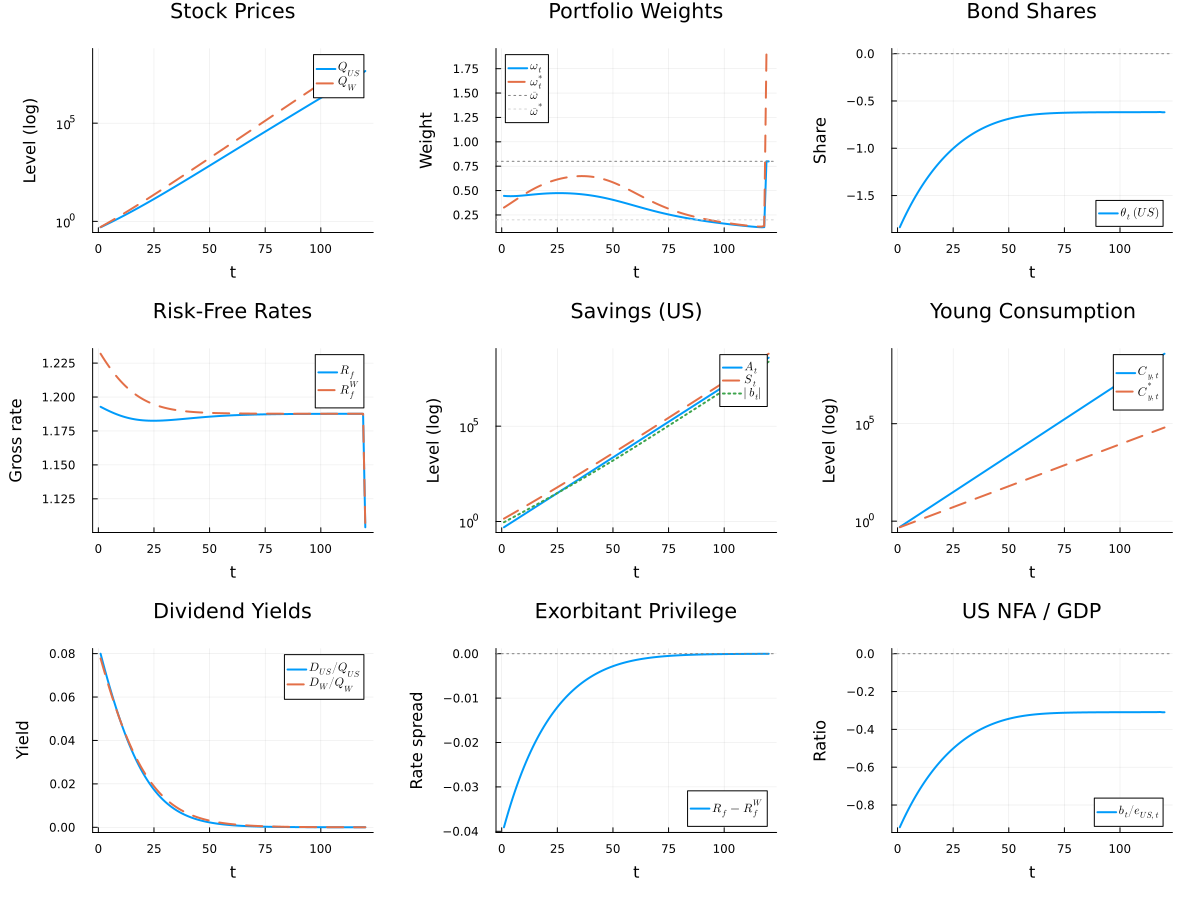

In [6]:
tt = 1:T

Q_US_vec  = [u_path[t].Q_US for t in tt]
Q_W_vec   = [u_path[t].Q_W  for t in tt]
ω_vec     = [u_path[t].ω for t in tt]
ωs_vec    = [u_path[t].ω_star for t in tt]
θ_vec     = [u_path[t].θ for t in tt]
θUs_vec   = [u_path[t].θ_US_star for t in tt]
Rf_vec    = [u_path[t].R_f for t in tt]
RfW_vec   = [u_path[t].R_f_W for t in tt]
S_vec     = [u_path[t].S for t in tt]
Ss_vec    = [u_path[t].S_star for t in tt]
A_vec     = [u_path[t].A for t in tt]
As_vec    = [u_path[t].A_star for t in tt]
Cy_vec    = [u_path[t].C_y for t in tt]
Cys_vec   = [u_path[t].C_y_star for t in tt]
b_vec     = [u_path[t].b for t in tt]
bUs_vec   = [u_path[t].b_US_star for t in tt]

# ── Panel 1: Stock Prices ──
pl1 = plot(tt, Q_US_vec, label=L"Q_{US}", lw=2, yscale=:log10,
           title="Stock Prices", xlabel="t", ylabel="Level (log)")
plot!(pl1, tt, Q_W_vec, label=L"Q_W", lw=2, ls=:dash)

# ── Panel 2: Portfolio Weights ──
pl2 = plot(tt, ω_vec, label=L"\omega_t", lw=2,
           title="Portfolio Weights", xlabel="t", ylabel="Weight")
plot!(pl2, tt, ωs_vec, label=L"\omega^*_t", lw=2, ls=:dash)
hline!(pl2, [p.ω̄], ls=:dot, lc=:gray, label=L"\bar{\omega}")
hline!(pl2, [p.ω̄_star], ls=:dot, lc=:lightgray, label=L"\bar{\omega}^*")

# ── Panel 3: Bond Shares ──
pl3 = plot(tt, θ_vec, label=L"\theta_t\ (US)", lw=2,
           title="Bond Shares", xlabel="t", ylabel="Share")
hline!(pl3, [0.0], ls=:dot, lc=:gray, label="")

# ── Panel 4: Risk-Free Rates ──
pl4 = plot(tt, Rf_vec, label=L"R_f", lw=2,
           title="Risk-Free Rates", xlabel="t", ylabel="Gross rate")
plot!(pl4, tt, RfW_vec, label=L"R^W_f", lw=2, ls=:dash)

# ── Panel 5: Saving Decomposition ──
pl5 = plot(tt, A_vec, label=L"A_t", lw=2, yscale=:log10,
           title="Savings (US)", xlabel="t", ylabel="Level (log)")
plot!(pl5, tt, S_vec, label=L"S_t", lw=2, ls=:dash)
plot!(pl5, tt, abs.(b_vec), label=L"|b_t|", lw=2, ls=:dot)

# ── Panel 6: Young-Age Consumption ──
pl6 = plot(tt, Cy_vec, label=L"C_{y,t}", lw=2, yscale=:log10,
           title="Young Consumption", xlabel="t", ylabel="Level (log)")
plot!(pl6, tt, Cys_vec, label=L"C^*_{y,t}", lw=2, ls=:dash)

# ── Panel 7: Dividend-to-Price Ratios ──
DQ_US = paths.D_US[1:T] ./ Q_US_vec
DQ_W  = paths.D_W[1:T]  ./ Q_W_vec
pl7 = plot(tt, DQ_US, label=L"D_{US}/Q_{US}", lw=2,
           title="Dividend Yields", xlabel="t", ylabel="Yield")
plot!(pl7, tt, DQ_W, label=L"D_W/Q_W", lw=2, ls=:dash)

# ── Panel 8: Exorbitant Privilege ──
ep_vec = Rf_vec .- RfW_vec
pl8 = plot(tt, ep_vec, label=L"R_f - R^W_f", lw=2,
           title="Exorbitant Privilege", xlabel="t", ylabel="Rate spread")
hline!(pl8, [0.0], ls=:dot, lc=:gray, label="")

# ── Panel 9: US Net Foreign Asset Position ──
nfa_ratio = b_vec ./ paths.e_US[1:T]
pl9 = plot(tt, nfa_ratio, label=L"b_t / e_{US,t}", lw=2,
           title="US NFA / GDP", xlabel="t", ylabel="Ratio")
hline!(pl9, [0.0], ls=:dot, lc=:gray, label="")

plot(pl1, pl2, pl3, pl4, pl5, pl6, pl7, pl8, pl9,
     layout=(3,3), size=(1200, 900), margin=5Plots.mm)

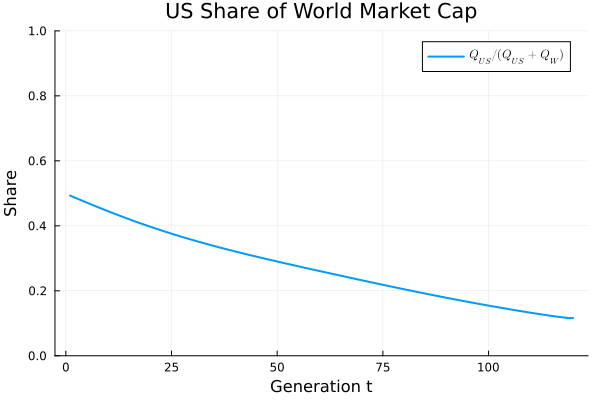

In [7]:
# ── US share of world market cap ──
us_share = Q_US_vec ./ (Q_US_vec .+ Q_W_vec)

plot(tt, us_share, lw=2, label=L"Q_{US}/(Q_{US}+Q_W)",
     xlabel="Generation t", ylabel="Share",
     title="US Share of World Market Cap",
     ylims=(0, 1))

## Summary

- The 6-equation system is solved by backward induction from $t = T$ to $t = 1$.
- All market-clearing conditions (stock, bond, goods) are verified to hold to machine precision.
- $\theta_t \le 0$ (US borrows) and $\theta^*_{US,t} > 0$ (RoW holds US bonds) throughout.
- The exorbitant privilege ($R_f > R^W_f$) is positive — the US borrows at a lower rate.
- The US dividend yield $D_{US}/Q_{US}$ declines over time, suggesting a growing bubble component.

**Next**: Notebook 04 computes the bubble diagnostics (Theorem 1 / Corollary 1).